# Data Preprocessing pada Customer Shopping Data Menggunakan Python dan Pandas
Tahap preprocessing dilakukan untuk menyiapkan dataset sebelum masuk ke proses analisis data lebih lanjut. Pada penelitian, data mentah sering kali belum siap digunakan secara langsung karena masih mungkin mengandung masalah seperti missing value, data duplikat, inkonsistensi format, outlier, atau skala data yang belum seragam.

Pada dataset Customer Shopping Data, preprocessing dilakukan melalui beberapa tahapan, yaitu data cleaning, penanganan missing value, deteksi outlier, transformasi data, normalisasi, reduksi data, dan diskritisasi. Tahapan ini sesuai dengan materi preprocessing pada data mining yang mencakup data cleaning, data integration, data transformation, data reduction, dan data discretization.

Tujuan akhir dari preprocessing adalah menghasilkan dataset yang lebih bersih, konsisten, terstruktur, dan siap digunakan untuk analisis lanjutan maupun pemodelan.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler

Pada tahap ini digunakan beberapa library utama, yaitu:

*   pandas untuk membaca, menampilkan, dan mengolah data tabular
*   numpy untuk membantu operasi numerik, terutama saat menangani outlier
*   matplotlib.pyplot untuk membuat visualisasi data
*  MinMaxScaler dari sklearn.preprocessing untuk normalisasi data dengan rentang 0 sampai 1
*   StandardScaler dari sklearn.preprocessing untuk standarisasi data menggunakan z-score

Library-library ini dipilih karena paling umum digunakan dalam preprocessing data berbasis Python.

In [ ]:
df = pd.read_csv("customer_shopping_data.csv")

print("5 Data Teratas:")
display(df.head())

print("Ukuran Dataset:")
print(df.shape)

5 Data Teratas:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Ukuran Dataset:
(99457, 10)


Pada tahap ini dataset dibaca dari file CSV menggunakan pd.read_csv(). Setelah itu ditampilkan 5 baris pertama untuk melihat gambaran awal isi dataset.

Selain itu, ukuran dataset juga ditampilkan menggunakan df.shape. Berdasarkan hasil pembacaan, dataset memiliki 99.457 baris dan 10 kolom. Jumlah ini menunjukkan bahwa dataset cukup besar dan layak digunakan untuk proses preprocessing.

In [ ]:
print("Informasi Dataset:")
df.info()

print("\nTipe Data Setiap Kolom:")
print(df.dtypes)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB

Tipe Data Setiap Kolom:
invoice_no         object
customer_id        object
gender             object
age                 int64
category           object
quantity            int64
price             float64
payment_method     object
invoice_date       object
shopping_ma

Tahap ini bertujuan untuk memahami struktur dataset secara umum. Melalui df.info() dan df.dtypes, dapat diketahui nama kolom, jumlah data non-null, dan tipe data tiap atribut.

Secara umum, dataset terdiri dari:
*   Data kategorik, seperti gender, category, payment_method, dan shopping_mall
*   Data numerik, seperti age, quantity, dan price
*   Data tanggal, yaitu invoice_date, yang pada awalnya masih terbaca sebagai tipe object

Keberagaman tipe data ini membuat dataset cocok untuk preprocessing, karena memungkinkan penerapan beberapa teknik seperti pembersihan data, encoding, transformasi, normalisasi, dan diskritisasi.

# Data Cleaning
### Mengecek Missing Value

In [ ]:
print("Jumlah Missing Value pada Setiap Kolom:")
print(df.isnull().sum())

Jumlah Missing Value pada Setiap Kolom:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


Langkah pertama dalam data cleaning adalah memeriksa apakah terdapat nilai yang hilang pada dataset. Pengecekan dilakukan menggunakan df.isnull().sum() untuk melihat jumlah missing value pada setiap kolom.

Berdasarkan hasil pengecekan, tidak ditemukan missing value pada seluruh kolom dataset. Artinya, dataset dalam kondisi lengkap. Meskipun demikian, langkah ini tetap perlu dilakukan dan didokumentasikan karena merupakan bagian penting dari preprocessing.

### Mengecek Data Duplikat

In [ ]:
print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
0


Setelah missing value, tahap berikutnya adalah memeriksa data duplikat. Data duplikat dapat menyebabkan bias dalam analisis karena satu observasi yang sama tercatat lebih dari satu kali.

Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada dataset. Dengan demikian, tidak diperlukan proses penghapusan duplikasi.

###Mengecek Nilai Unik pada Kolom Kategorik

In [ ]:
categorical_cols = ['gender', 'category', 'payment_method', 'shopping_mall']

for col in categorical_cols:
    print(f"\nNilai unik pada kolom {col}:")
    print(df[col].unique())


Nilai unik pada kolom gender:
['Female' 'Male']

Nilai unik pada kolom category:
['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']

Nilai unik pada kolom payment_method:
['Credit Card' 'Debit Card' 'Cash']

Nilai unik pada kolom shopping_mall:
['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center']


Tahap ini dilakukan untuk melihat apakah ada inkonsistensi dalam penulisan data kategorik. Misalnya, kategori yang sebenarnya sama tetapi ditulis dengan format berbeda, seperti:

*  huruf besar dan kecil yang tidak konsisten
*   adanya spasi di awal atau akhir teks
*   variasi penulisan kategori yang seharusnya sama

Dengan melihat nilai unik pada tiap kolom kategorik, kita dapat memastikan konsistensi data sebelum masuk ke tahap transformasi.

###Standarisasi Teks pada Kolom Kategorik

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Data Setelah Standarisasi Teks:")
display(df.head())

Data Setelah Standarisasi Teks:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol Avm
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Pada tahap ini dilakukan standarisasi pada kolom kategorik. Proses yang dilakukan meliputi:

*   str.strip() untuk menghapus spasi berlebih
*   str.title() untuk menyeragamkan format huruf

Langkah ini penting agar kategori yang sama tidak terbaca sebagai kategori berbeda hanya karena format penulisan yang tidak konsisten.

Sebagai contoh, nilai seperti "male", " Male", dan "MALE" dapat diseragamkan menjadi "Male".

###Konversi Tipe Data Tanggal

In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

print("5 Data Tanggal Setelah Konversi:")
display(df[['invoice_date']].head())

print("Jumlah Tanggal Gagal Dikonversi:")
print(df['invoice_date'].isnull().sum())

5 Data Tanggal Setelah Konversi:


,invoice_date
0,2022-08-05
1,2021-12-12
2,2021-11-09
3,2021-05-16
4,2021-10-24


Jumlah Tanggal Gagal Dikonversi:
0


Kolom invoice_date pada awalnya masih berbentuk object atau string. Agar dapat dianalisis dengan baik, kolom ini perlu diubah ke format datetime menggunakan pd.to_datetime().

Parameter dayfirst=True digunakan karena format tanggal kemungkinan menggunakan urutan hari-bulan-tahun. Sementara itu, errors='coerce' digunakan agar nilai yang gagal dikonversi otomatis menjadi NaT.

Setelah konversi, dilakukan pengecekan ulang untuk melihat apakah ada tanggal yang tidak valid. Jika jumlah nilai null setelah konversi adalah 0, berarti seluruh data tanggal berhasil diubah.

# Penanganan Missing Value

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
object_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in object_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

if df['invoice_date'].isnull().sum() > 0:
    df['invoice_date'] = df['invoice_date'].fillna(df['invoice_date'].mode()[0])

print("Missing Value Setelah Penanganan:")
print(df.isnull().sum())

Missing Value Setelah Penanganan:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


Dalam preprocessing, missing value dapat ditangani dengan pendekatan yang berbeda sesuai tipe datanya:

*  Untuk data numerik, digunakan median
*   Untuk data kategorik, digunakan modus
*   Untuk data tanggal, dapat diisi menggunakan nilai modus atau pendekatan lain sesuai kebutuhan

Pada dataset ini, karena tidak ada missing value sejak awal, maka proses imputasi tidak mengubah isi data. Namun, langkah ini tetap penting untuk menunjukkan kesiapan alur preprocessing apabila digunakan pada dataset lain.

# Deteksi Outlier
###Visualisasi Distribusi Data Numerik

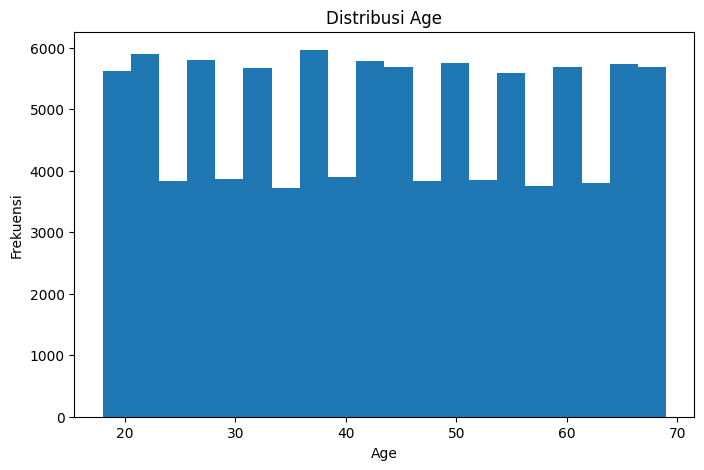

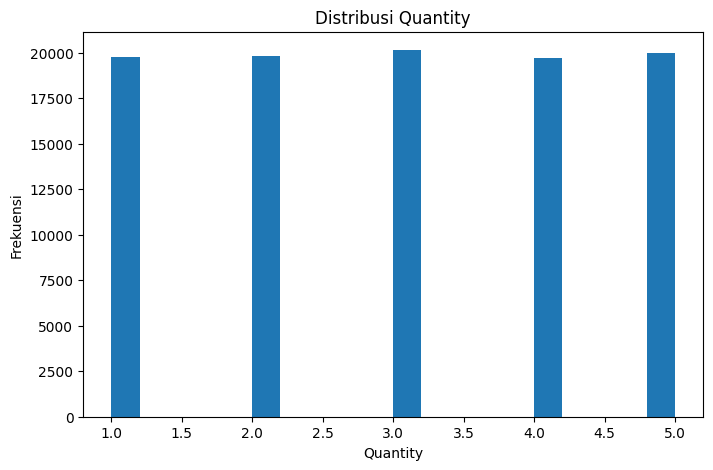

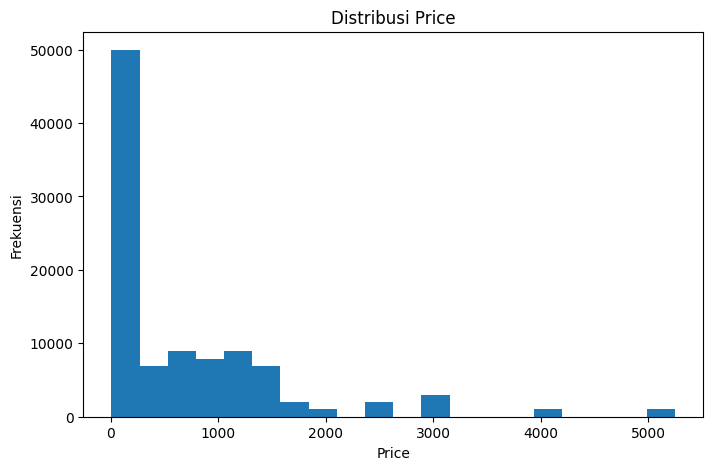

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20)
plt.title("Distribusi Age")
plt.xlabel("Age")
plt.ylabel("Frekuensi")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['quantity'], bins=20)
plt.title("Distribusi Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frekuensi")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=20)
plt.title("Distribusi Price")
plt.xlabel("Price")
plt.ylabel("Frekuensi")
plt.show()

Sebelum mendeteksi outlier, dilakukan visualisasi distribusi data numerik menggunakan histogram. Visualisasi ini bertujuan untuk melihat pola sebaran data pada variabel age, quantity, dan price.

Melalui histogram, dapat diamati apakah data memiliki distribusi yang merata, cenderung miring, atau memiliki nilai yang terkonsentrasi pada rentang tertentu. Selain itu, histogram juga membantu memberikan gambaran awal mengenai kemungkinan adanya nilai ekstrem pada dataset.

###Visualisasi Outlier Sebelum Penanganan

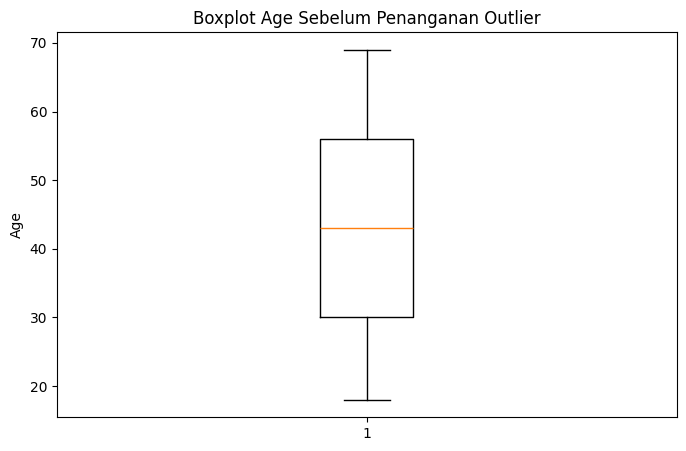

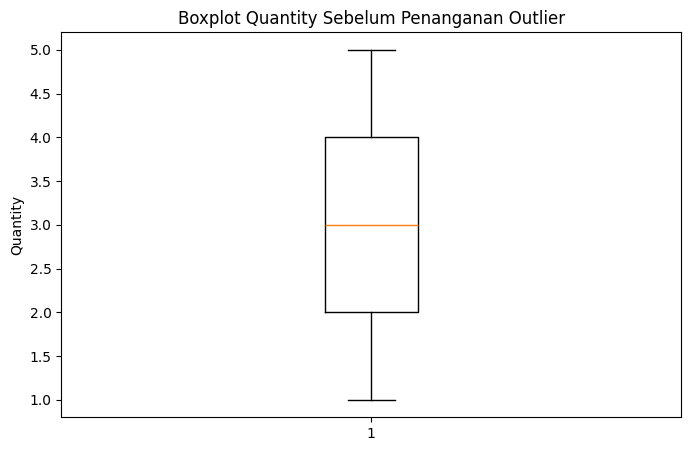

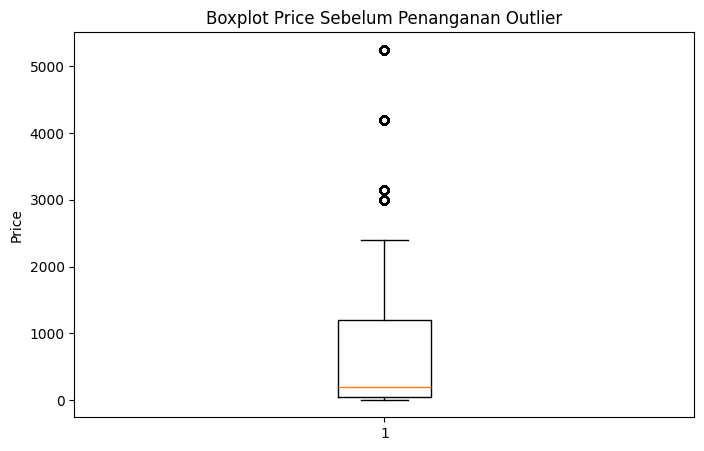

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['age'])
plt.title("Boxplot Age Sebelum Penanganan Outlier")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df['quantity'])
plt.title("Boxplot Quantity Sebelum Penanganan Outlier")
plt.ylabel("Quantity")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df['price'])
plt.title("Boxplot Price Sebelum Penanganan Outlier")
plt.ylabel("Price")
plt.show()

Setelah melihat distribusi data, dilakukan visualisasi menggunakan boxplot untuk mendeteksi outlier. Boxplot membantu memperlihatkan data yang berada jauh di luar sebaran utama.

Pada visualisasi ini, nilai yang berada di luar whisker dapat diindikasikan sebagai outlier. Dengan demikian, boxplot digunakan sebagai pendukung visual sebelum dilakukan deteksi outlier secara numerik menggunakan metode IQR.

###Mendeteksi Outlier dengan Metode IQR

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

outlier_cols = ['age', 'quantity', 'price']

for col in outlier_cols:
    lower, upper, outliers = detect_outliers_iqr(df, col)
    print(f"\nKolom: {col}")
    print("Batas bawah:", lower)
    print("Batas atas :", upper)
    print("Jumlah outlier:", len(outliers))


Kolom: age
Batas bawah: -9.0
Batas atas : 95.0
Jumlah outlier: 0

Kolom: quantity
Batas bawah: -1.0
Batas atas : 7.0
Jumlah outlier: 0

Kolom: price
Batas bawah: -1686.8549999999998
Batas atas : 2932.625
Jumlah outlier: 5024


Outlier adalah nilai yang terlalu jauh dari sebaran utama data. Dalam dataset transaksi belanja, outlier dapat muncul pada variabel seperti usia, jumlah pembelian, atau harga barang.

Deteksi outlier pada penelitian ini dilakukan menggunakan metode Interquartile Range (IQR). Metode ini menghitung:

*   Kuartil pertama (Q1)
*   Kuartil ketiga (Q3)
*   IQR = Q3 - Q1

Kemudian ditentukan batas bawah dan batas atas:

*   Batas bawah = Q1 - 1.5 × IQR
*   Batas atas = Q3 + 1.5 × IQR

Nilai di luar rentang tersebut dianggap sebagai outlier.

###Menangani Outlier dengan Metode Capping

In [ ]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

for col in outlier_cols:
    df = cap_outliers(df, col)

print("Statistik Deskriptif Setelah Penanganan Outlier:")
display(df[outlier_cols].describe())

Statistik Deskriptif Setelah Penanganan Outlier:


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,649.590907
std,14.990054,1.413025,797.179372
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,2932.625000


Setelah outlier terdeteksi, langkah berikutnya adalah menanganinya. Pada tugas ini digunakan metode capping, yaitu:

*   Nilai yang lebih kecil dari batas bawah diganti menjadi batas bawah
*   Nilai yang lebih besar dari batas atas diganti menjadi batas atas

Metode ini dipilih karena lebih aman dibanding langsung menghapus baris data. Dengan capping, jumlah observasi tetap dipertahankan, tetapi pengaruh nilai ekstrem dapat dikurangi.

###Visualisasi Outlier Setelah Penanganan

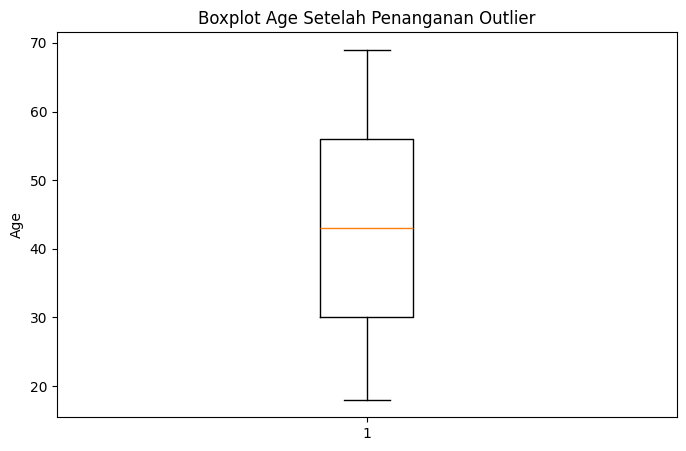

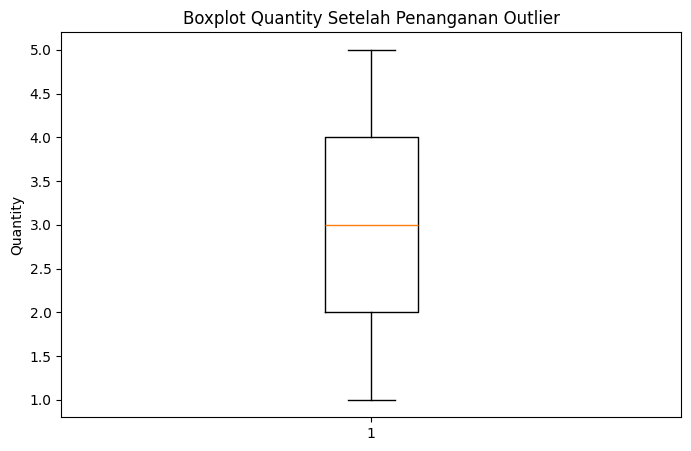

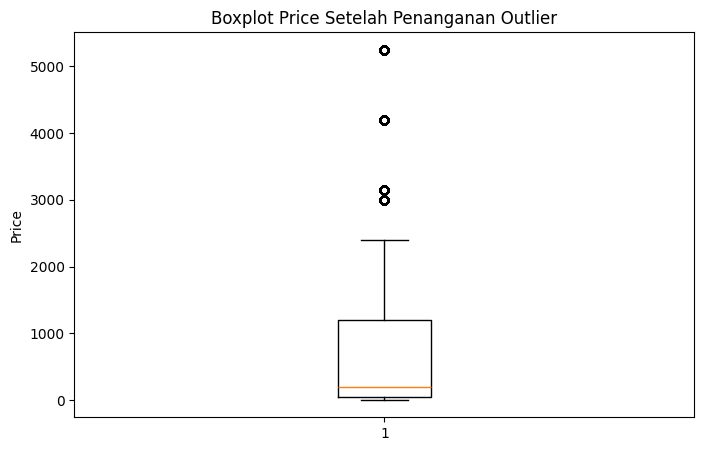

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['age'])
plt.title("Boxplot Age Setelah Penanganan Outlier")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df['quantity'])
plt.title("Boxplot Quantity Setelah Penanganan Outlier")
plt.ylabel("Quantity")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df['price'])
plt.title("Boxplot Price Setelah Penanganan Outlier")
plt.ylabel("Price")
plt.show()

Setelah proses capping dilakukan, visualisasi boxplot dibuat kembali untuk melihat perubahan distribusi data. Boxplot setelah penanganan outlier digunakan untuk membandingkan kondisi data sebelum dan sesudah proses capping.

Dari visualisasi ini dapat dilihat bahwa nilai ekstrem menjadi lebih terkendali, sehingga distribusi data menjadi lebih stabil untuk proses analisis selanjutnya.

# Data Integration

In [ ]:
print("Data Integration:")
print("Dataset berasal dari satu sumber, sehingga integrasi data tidak dilakukan.")

Data Integration:
Dataset berasal dari satu sumber, sehingga integrasi data tidak dilakukan.


Pada materi preprocessing, data integration merupakan tahap penggabungan data dari beberapa sumber yang berbeda. Namun, pada kasus ini dataset hanya berasal dari satu file, sehingga tidak ada proses integrasi data.

Jika dimasukkan ke dalam laporan, penjelasan yang tepat adalah bahwa tahap data integration tidak diterapkan karena data penelitian hanya menggunakan satu sumber data.

# Data Transformation
###Membuat Fitur Baru

In [ ]:
df['total_spent'] = df['price'] * df['quantity']

print("Data Setelah Membuat Fitur total_spent:")
display(df[['price', 'quantity', 'total_spent']].head())

Data Setelah Membuat Fitur total_spent:


,price,quantity,total_spent
0,1500.400,5.0,7502.000
1,1800.510,3.0,5401.530
2,300.080,1.0,300.080
3,2932.625,5.0,14663.125
4,60.600,4.0,242.400


Transformasi pertama yang dilakukan adalah membuat fitur baru bernama total_spent. Kolom ini diperoleh dari hasil perkalian price dengan quantity.

Tujuan pembuatan fitur ini adalah agar informasi transaksi menjadi lebih informatif. Dibanding melihat harga dan jumlah beli secara terpisah, kolom total_spent langsung menunjukkan total pengeluaran pada setiap transaksi.

###Visualisasi Total Belanja

In [ ]:
df['total_spent'] = df['price'] * df['quantity']

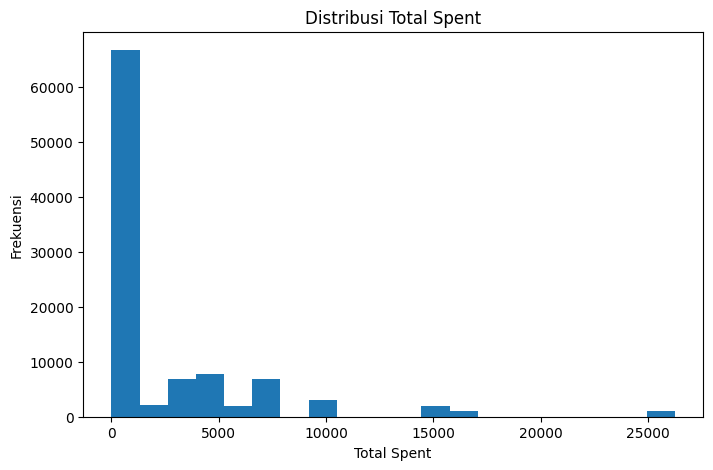

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['total_spent'], bins=20)
plt.title("Distribusi Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frekuensi")
plt.show()

Setelah fitur total_spent dibuat, dilakukan visualisasi menggunakan histogram untuk melihat distribusi total pengeluaran pelanggan. Visualisasi ini membantu memahami bagaimana pola belanja tersebar dalam dataset.

Melalui grafik ini, dapat diamati apakah sebagian besar transaksi berada pada pengeluaran rendah, sedang, atau tinggi.

###Ekstraksi Komponen Tanggal

In [ ]:
df['invoice_day'] = df['invoice_date'].dt.day
df['invoice_month'] = df['invoice_date'].dt.month
df['invoice_year'] = df['invoice_date'].dt.year

print("Data Setelah Ekstraksi Tanggal:")
display(df[['invoice_date', 'invoice_day', 'invoice_month', 'invoice_year']].head())

Data Setelah Ekstraksi Tanggal:


,invoice_date,invoice_day,invoice_month,invoice_year
0,2022-08-05,5,8,2022
1,2021-12-12,12,12,2021
2,2021-11-09,9,11,2021
3,2021-05-16,16,5,2021
4,2021-10-24,24,10,2021


Setelah kolom tanggal berhasil dikonversi ke datetime, kita dapat mengekstrak beberapa informasi tambahan, yaitu:


*  hari transaksi
*   bulan transaksi
*   tahun transaksi

Informasi ini berguna jika nantinya ingin dilakukan analisis perilaku belanja berdasarkan waktu.

###Encoding Variabel Kategorik

In [ ]:
df['gender_encoded'] = df['gender'].map({'Female': 0, 'Male': 1})

df_encoded = pd.get_dummies(
    df,
    columns=['category', 'payment_method', 'shopping_mall'],
    drop_first=True
)

print("Data Setelah Encoding:")
display(df_encoded.head())

Data Setelah Encoding:


,invoice_no,customer_id,gender,age,quantity,price,invoice_date,total_spent,invoice_day,invoice_month,...,payment_method_Debit Card,shopping_mall_Emaar Square Mall,shopping_mall_Forum Istanbul,shopping_mall_Istinye Park,shopping_mall_Kanyon,shopping_mall_Mall Of Istanbul,shopping_mall_Metrocity,shopping_mall_Metropol Avm,shopping_mall_Viaport Outlet,shopping_mall_Zorlu Center
0,I138884,C241288,Female,28.0,5.0,1500.400,2022-08-05,7502.000,5,8,...,False,False,False,False,True,False,False,False,False,False
1,I317333,C111565,Male,21.0,3.0,1800.510,2021-12-12,5401.530,12,12,...,True,False,True,False,False,False,False,False,False,False
2,I127801,C266599,Male,20.0,1.0,300.080,2021-11-09,300.080,9,11,...,False,False,False,False,False,False,True,False,False,False
3,I173702,C988172,Female,66.0,5.0,2932.625,2021-05-16,14663.125,16,5,...,False,False,False,False,False,False,False,True,False,False
4,I337046,C189076,Female,53.0,4.0,60.600,2021-10-24,242.400,24,10,...,False,False,False,False,True,False,False,False,False,False


Banyak metode analisis data dan machine learning tidak dapat langsung memproses data berbentuk teks. Oleh karena itu, data kategorik perlu diubah menjadi numerik.

Pada tahap ini digunakan dua pendekatan:


*   Label encoding sederhana untuk kolom gender
*   One-hot encoding untuk kolom category, payment_method, dan shopping_mall

Penggunaan drop_first=True bertujuan untuk mengurangi redundansi kolom hasil encoding.

###Visualisasi Jumlah Transaksi per Kategori

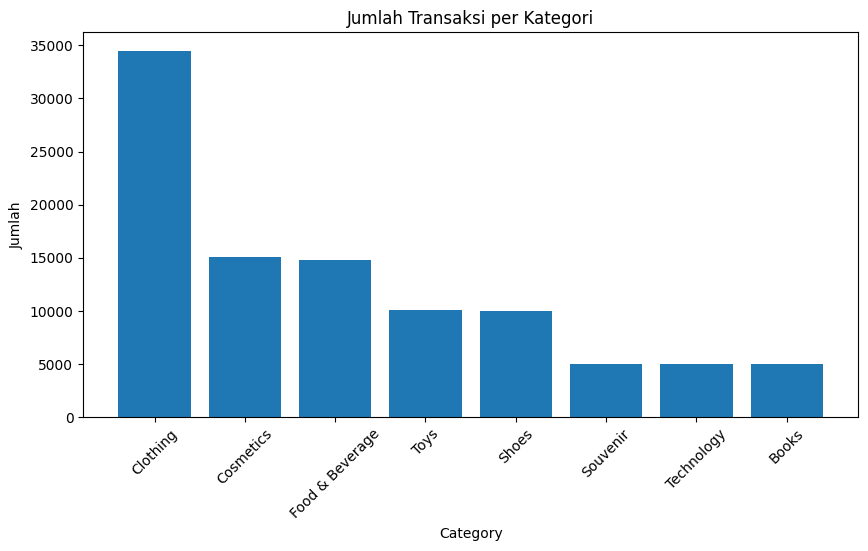

In [ ]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Jumlah Transaksi per Kategori")
plt.xlabel("Category")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

Bar chart digunakan untuk melihat jumlah transaksi pada setiap kategori produk. Visualisasi ini membantu menunjukkan kategori mana yang paling sering muncul dalam dataset.

Grafik ini juga memudahkan pembacaan pola distribusi data kategorik sebelum atau sesudah dilakukan encoding.

#Normalisasi Data
###Normalisasi dengan Min-Max Scaling

In [ ]:
scale_cols = ['age', 'quantity', 'price', 'total_spent']

minmax_scaler = MinMaxScaler()
df_encoded[['age_minmax', 'quantity_minmax', 'price_minmax', 'total_spent_minmax']] = \
    minmax_scaler.fit_transform(df_encoded[scale_cols])

display(df_encoded[['age', 'age_minmax', 'price', 'price_minmax', 'total_spent', 'total_spent_minmax']].head())

,age,age_minmax,price,price_minmax,total_spent,total_spent_minmax
0,28.0,0.196078,1500.400,0.510751,7502.000,0.511449
1,21.0,0.058824,1800.510,0.613269,5401.530,0.368150
2,20.0,0.039216,300.080,0.100721,300.080,0.020115
3,66.0,0.941176,2932.625,1.000000,14663.125,1.000000
4,53.0,0.686275,60.600,0.018914,242.400,0.016180


Normalisasi dilakukan agar skala antar variabel numerik menjadi lebih seragam. Pada Min-Max Scaling, nilai setiap variabel akan diubah ke rentang 0 sampai 1.

Langkah ini penting terutama jika variabel memiliki satuan dan rentang nilai yang sangat berbeda, misalnya antara age, price, dan total_spent.

###Standarisasi dengan Z-Score

In [ ]:
standard_scaler = StandardScaler()
df_encoded[['age_zscore', 'quantity_zscore', 'price_zscore', 'total_spent_zscore']] = \
    standard_scaler.fit_transform(df_encoded[scale_cols])

display(df_encoded[['age', 'age_zscore', 'price', 'price_zscore', 'total_spent', 'total_spent_zscore']].head())

,age,age_zscore,price,price_zscore,total_spent,total_spent_zscore
0,28.0,-1.029160,1500.400,1.067280,7502.000,1.478113
1,21.0,-1.496139,1800.510,1.443746,5401.530,0.875764
2,20.0,-1.562850,300.080,-0.438437,300.080,-0.587173
3,66.0,1.505867,2932.625,2.863904,14663.125,3.531700
4,53.0,0.638621,60.600,-0.738847,242.400,-0.603714


Selain Min-Max Scaling, dilakukan juga standarisasi menggunakan Z-score. Pada metode ini, data diubah sehingga memiliki:

*   rata-rata mendekati 0
*   standar deviasi mendekati 1

Metode ini sering digunakan saat analisis memerlukan distribusi data yang terstandarisasi.

###Visualisasi Perbandingan Sebelum dan Sesudah Normalisasi

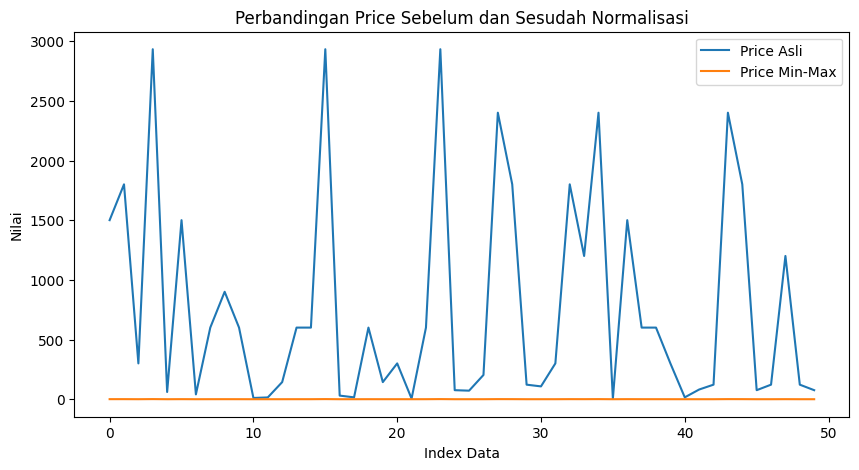

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df_encoded['price'].head(50).values, label='Price Asli')
plt.plot(df_encoded['price_minmax'].head(50).values, label='Price Min-Max')
plt.title("Perbandingan Price Sebelum dan Sesudah Normalisasi")
plt.xlabel("Index Data")
plt.ylabel("Nilai")
plt.legend()
plt.show()

Visualisasi ini digunakan untuk membandingkan nilai data sebelum dan sesudah normalisasi. Dari grafik terlihat bahwa nilai hasil normalisasi berada pada skala yang lebih kecil dan lebih seragam dibandingkan data asli.

Grafik ini membantu menunjukkan bahwa normalisasi berhasil menyamakan rentang nilai data numerik.

#Data Reduction

In [ ]:
columns_to_drop = ['invoice_no', 'customer_id', 'invoice_date']
df_reduced = df_encoded.drop(columns=columns_to_drop)

print("Data Setelah Reduksi:")
display(df_reduced.head())

print("Ukuran Data Setelah Reduksi:")
print(df_reduced.shape)

Data Setelah Reduksi:


,gender,age,quantity,price,total_spent,invoice_day,invoice_month,invoice_year,gender_encoded,category_Clothing,...,shopping_mall_Viaport Outlet,shopping_mall_Zorlu Center,age_minmax,quantity_minmax,price_minmax,total_spent_minmax,age_zscore,quantity_zscore,price_zscore,total_spent_zscore
0,Female,28.0,5.0,1500.400,7502.000,5,8,2022,0,True,...,False,False,0.196078,1.00,0.510751,0.511449,-1.029160,1.412984,1.067280,1.478113
1,Male,21.0,3.0,1800.510,5401.530,12,12,2021,1,False,...,False,False,0.058824,0.50,0.613269,0.368150,-1.496139,-0.002426,1.443746,0.875764
2,Male,20.0,1.0,300.080,300.080,9,11,2021,1,True,...,False,False,0.039216,0.00,0.100721,0.020115,-1.562850,-1.417837,-0.438437,-0.587173
3,Female,66.0,5.0,2932.625,14663.125,16,5,2021,0,False,...,False,False,0.941176,1.00,1.000000,1.000000,1.505867,1.412984,2.863904,3.531700
4,Female,53.0,4.0,60.600,242.400,24,10,2021,0,False,...,False,False,0.686275,0.75,0.018914,0.016180,0.638621,0.705279,-0.738847,-0.603714


Ukuran Data Setelah Reduksi:
(99457, 35)


Data reduction bertujuan untuk mengurangi atribut yang dianggap kurang relevan terhadap analisis utama. Pada tahap ini, beberapa kolom dihapus, yaitu:

*   invoice_no
*   customer_id
*   invoice_date

Kolom-kolom tersebut lebih berfungsi sebagai identitas transaksi dan identitas pelanggan, sehingga tidak terlalu informatif untuk analisis numerik lanjutan.

Dengan reduksi data, dataset menjadi lebih ringkas dan efisien.

#Data Discretization
###Diskritisasi Variabel Age

In [ ]:
df_reduced['age_group'] = pd.cut(
    df_reduced['age'],
    bins=[0, 25, 45, 70],
    labels=['Young', 'Adult', 'Old']
)

display(df_reduced[['age', 'age_group']].head())

,age,age_group
0,28.0,Adult
1,21.0,Young
2,20.0,Young
3,66.0,Old
4,53.0,Old


Diskritisasi adalah proses mengubah data numerik kontinu menjadi data kategorik berbasis interval.

Pada tahap ini, variabel age dibagi menjadi tiga kategori:

*   Young
*   Adult
*   Old

Pembagian ini membantu menyederhanakan interpretasi data, khususnya jika ingin melihat kelompok usia pelanggan.

###Diskritisasi Variabel Total Spending

In [ ]:
df_reduced['spending_level'] = pd.cut(
    df_reduced['total_spent'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

display(df_reduced[['total_spent', 'spending_level']].head())

,total_spent,spending_level
0,7502.000,Medium
1,5401.530,Medium
2,300.080,Low
3,14663.125,High
4,242.400,Low


Selain usia, variabel total_spent juga didiskritisasi menjadi tiga kategori:

*   Low
*   Medium
*   High

Diskritisasi ini memudahkan pengelompokan tingkat pengeluaran pelanggan, sehingga analisis menjadi lebih sederhana dan mudah dipahami.

#Dataset Akhir

In [ ]:
print("Dataset Final Setelah Preprocessing:")
display(df_reduced.head())

print("Ukuran Dataset Final:")
print(df_reduced.shape)

Dataset Final Setelah Preprocessing:


,gender,age,quantity,price,total_spent,invoice_day,invoice_month,invoice_year,gender_encoded,category_Clothing,...,age_minmax,quantity_minmax,price_minmax,total_spent_minmax,age_zscore,quantity_zscore,price_zscore,total_spent_zscore,age_group,spending_level
0,Female,28.0,5.0,1500.400,7502.000,5,8,2022,0,True,...,0.196078,1.00,0.510751,0.511449,-1.029160,1.412984,1.067280,1.478113,Adult,Medium
1,Male,21.0,3.0,1800.510,5401.530,12,12,2021,1,False,...,0.058824,0.50,0.613269,0.368150,-1.496139,-0.002426,1.443746,0.875764,Young,Medium
2,Male,20.0,1.0,300.080,300.080,9,11,2021,1,True,...,0.039216,0.00,0.100721,0.020115,-1.562850,-1.417837,-0.438437,-0.587173,Young,Low
3,Female,66.0,5.0,2932.625,14663.125,16,5,2021,0,False,...,0.941176,1.00,1.000000,1.000000,1.505867,1.412984,2.863904,3.531700,Old,High
4,Female,53.0,4.0,60.600,242.400,24,10,2021,0,False,...,0.686275,0.75,0.018914,0.016180,0.638621,0.705279,-0.738847,-0.603714,Old,Low


Ukuran Dataset Final:
(99457, 37)


Dataset final merupakan hasil dari seluruh tahapan preprocessing yang telah dilakukan, mulai dari pembersihan data, transformasi, normalisasi, reduksi, hingga diskritisasi.

Dataset ini sudah dalam kondisi yang lebih baik karena:

*   format data lebih konsisten
*   variabel kategorik telah diubah ke bentuk numerik
*   nilai ekstrem telah ditangani
*   fitur tambahan telah dibuat
*   data lebih siap untuk tahap analisis lanjutan


#Menyimpan Hasil Preprocessing

In [ ]:
df_reduced.to_csv("customer_shopping_data_preprocessed.csv", index=False)
print("File hasil preprocessing berhasil disimpan.")

File hasil preprocessing berhasil disimpan.


Tahap terakhir adalah menyimpan dataset hasil preprocessing ke dalam file CSV baru. File ini nantinya dapat digunakan untuk proses analisis berikutnya, seperti klasifikasi, clustering, atau visualisasi data.

# KESIMPULAN
Berdasarkan hasil preprocessing, dataset Customer Shopping Data berada dalam kondisi yang cukup baik karena tidak ditemukan missing value maupun data duplikat. Meskipun demikian, preprocessing tetap dilakukan untuk memastikan kualitas data semakin baik dan struktur dataset semakin siap untuk dianalisis.

Tahapan preprocessing yang dilakukan mencakup data cleaning, penanganan missing value, deteksi dan penanganan outlier, transformasi data, normalisasi, reduksi data, dan diskritisasi. Hasil dari tahapan ini menunjukkan bahwa dataset menjadi lebih konsisten, lebih informatif, dan lebih sesuai untuk proses data mining lebih lanjut. Dengan demikian, dataset hasil preprocessing dapat digunakan sebagai dasar analisis lanjutan secara lebih optimal.

## 🎁 Paket Pro Gratis untuk Gemini &amp; Colab bagi Mahasiswa di Amerika Serikat 🎓

Dapatkan akses lebih luas ke model kami yang paling akurat, Gemini 3 Pro, untuk kebutuhan coding tingkat lanjut, riset kompleks, dan project inovatif. Model tersebut didukung oleh resource komputasi tinggi khusus Colab untuk data science dan machine learning.

Dapatkan penawaran gratis Gemini di <a href="https://gemini.google/students?utm_source=colab&amp;utm_medium=banner&amp;utm_campaign=students_xpa_us-colab-banner">gemini.google/students</a>.  
Dapatkan penawaran gratis Colab di <a href="https://colab.research.google.com/signup">colab.research.google.com/signup</a>.  
Persyaratan Berlaku.

## Akses model AI populer melalui Google-Colab-AI Tanpa Kunci API
Semua pengguna memiliki akses ke sebagian besar LLM populer melalui library Python <code>google-colab-ai</code>, dan pengguna berbayar memiliki akses ke pilihan model yang lebih banyak. Untuk mengetahui detail selengkapnya, lihat <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">memulai penggunaan google colab ai</a>.



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Pelajari Gemini API
Gemini API memberi Anda akses ke model Gemini yang dibuat oleh Google DeepMind. Sejak awal, model Gemini dirancang agar bersifat multimodal, sehingga Anda dapat melakukan analisis dengan lancar menggunakan teks, gambar, kode, dan audio.

**Ingin tahu cara memulai?**
*  Buka <a href="https://aistudio.google.com/">Google AI Studio</a> dan login dengan Akun Google Anda.
*  <a href="https://aistudio.google.com/app/apikey">Membuat kunci API</a>.
* Gunakan panduan memulai untuk <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a>, atau panggil REST API menggunakan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Temukan kemampuan canggih Gemini**
*  Bereksperimenlah dengan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">output multimodal</a> Gemini, yang menggabungkan teks dan gambar secara iteratif.
*  Temukan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">Multimodal Live API</a> &#40;demo tersedia <a href="https://aistudio.google.com/live">di sini</a>&#41;.
*  Pelajari cara <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">menganalisis gambar dan mendeteksi item di foto Anda</a> menggunakan Gemini &#40;tersedia juga bonus <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">versi 3D</a>&#41;.
*  Dapatkan manfaat dari <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">model pemikiran Gemini</a>, yang mampu menyelesaikan berbagai tugas kompleks dengan pemikiran internalnya.
      
**Pelajari kasus penggunaan yang kompleks**
*  Gunakan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">kemampuan grounding Gemini</a> untuk membuat laporan tentang perusahaan berdasarkan informasi yang dapat ditemukan model di internet.
*  Ekstrak <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">invoice dan data formulir dari PDF</a> dengan cara yang terstruktur.
*  Buat <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">ilustrasi berdasarkan seluruh buku</a> menggunakan jendela konteks besar Gemini dan Imagen.

Untuk mempelajari lebih lanjut, lihat <a href="https://github.com/google-gemini/cookbook">cookbook Gemini</a> atau buka <a href="https://ai.google.dev/docs/">dokumentasi Gemini API</a>.


Colab kini memiliki fitur AI yang didukung oleh <a href="https://gemini.google.com">Gemini</a>. Video berikut memberikan informasi tentang cara menggunakan fitur ini, baik jika Anda baru mengenal Python, atau sudah berpengalaman.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  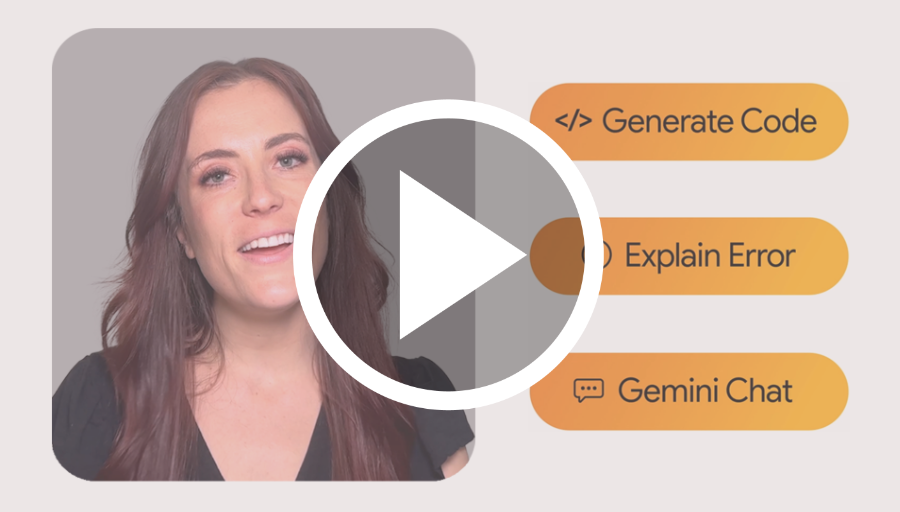
  </a>
</center>

<div class="markdown-google-sans">
  <h2>Apa itu Colab?</h2>
</div>

Colab, atau "Colaboratory", memungkinkan Anda menulis dan mengeksekusi Python di browser, dengan
- Tidak memerlukan konfigurasi
- Akses tanpa biaya ke GPU
- Berbagi dengan mudah

Baik Anda seorang <strong>siswa</strong>, <strong>data scientist</strong>, atau <strong>peneliti AI</strong>, Colab dapat memudahkan pekerjaan Anda. Tonton <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Pengantar Colab</a> atau <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Fitur Colab yang Mungkin Belum Anda Ketahui</a> untuk mempelajari lebih lanjut, atau cukup mulai di bawah ini.

<div class="markdown-google-sans">

## <strong>Memulai</strong>
</div>

Dokumen yang sedang Anda baca bukan halaman statis. Ini media interaktif bernama <strong>notebook Colab</strong> yang memungkinkan Anda menulis dan mengeksekusi kode.

Misalnya, berikut ini <strong>kode sel</strong> dengan skrip Python pendek yang mengomputasi sebuah nilai, menyimpannya dalam suatu variabel, dan mencetak hasilnya:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Untuk mengeksekusi kode dalam sel di atas, pilih kode tersebut dengan mengkliknya, kemudian tekan tombol putar di sebelah kiri kode atau gunakan pintasan keyboard "Command/Ctrl+Enter". Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Variabel yang Anda tentukan dalam sebuah sel nantinya dapat digunakan di sel lain:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Notebook Colab memungkinkan Anda menggabungkan <strong>kode yang dapat dijalankan</strong> dan <strong>rich text</strong> dalam satu dokumen, beserta <strong>gambar</strong>, <strong>HTML</strong>, <strong>LaTeX</strong>, dan lainnya. Saat Anda membuat notebook Colab Anda sendiri, notebook tersebut akan disimpan di akun Google Drive Anda. Anda dapat dengan mudah membagikan notebook Colab Anda dengan rekan kerja atau teman, sehingga memungkinkan mereka memberikan komentar di notebook Anda atau bahkan mengeditnya. Untuk mempelajari lebih lanjut, buka <a href="/notebooks/basic_features_overview.ipynb">Ringkasan Colab</a>. Untuk membuat notebook Colab baru, Anda dapat menggunakan menu File di atas, atau menggunakan link berikut: <a href="http://colab.research.google.com#create=true">buat notebook Colab baru</a>.

Notebook Colab adalah notebook Jupyter yang dihosting oleh Colab. Untuk mempelajari project Jupyter lebih lanjut, buka <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Ilmu data
</div>

Dengan Colab, Anda dapat memanfaatkan kecanggihan library Python yang populer untuk menganalisis dan memvisualisasikan data. Sel kode di bawah menggunakan <strong>numpy</strong> untuk menghasilkan beberapa data acak, dan menggunakan <strong>matplotlib</strong> untuk memvisualisasikannya. Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Anda dapat mengimpor data sendiri ke notebook Colab dari akun Google Drive Anda, termasuk dari spreadsheet, GitHub, dan berbagai sumber lainnya. Untuk mempelajari lebih lanjut pengimporan data dan bagaimana Colab dapat digunakan untuk ilmu data, lihat link di bawah pada bagian <a href="#working-with-data">Bekerja dengan Data</a>.

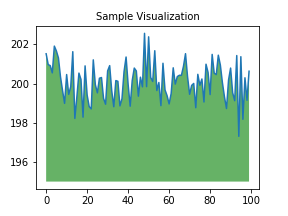

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Notebook Colab mengeksekusi kode di server cloud Google. Artinya, Anda dapat memanfaatkan kecanggihan hardware Google, termasuk <a href="#using-accelerated-hardware">GPU dan TPU</a>, terlepas dari kecanggihan komputer Anda. Yang Anda butuhkan hanyalah browser.

Misalnya, jika Anda harus menunggu kode <strong>pandas</strong> selesai dijalankan dan ingin mempercepat prosesnya, Anda dapat beralih ke Runtime GPU dan menggunakan library seperti <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> yang menyediakan akselerasi tanpa perubahan kode.

Untuk mempelajari lebih lanjut cara mempercepat pandas di Colab, lihat <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">panduan 10 menit</a> atau
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demo analisis data pasar saham AS</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Dengan Colab, Anda dapat mengimpor set data gambar, melatih pengklasifikasi gambar di dalamnya, dan mengevaluasi model hanya dengan <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">beberapa baris kode</a>.

Colab digunakan secara luas di komunitas machine learning dengan berbagai penerapan meliputi:
- Memulai TensorFlow
- Mengembangkan dan melatih jaringan neural
- Bereksperimen dengan TPU
- Menyebarkan riset AI
- Membuat tutorial

Untuk melihat sampel notebook Colab yang menunjukkan penerapan machine learning, lihat <a href="#machine-learning-examples">contoh machine learning</a> di bawah.

<div class="markdown-google-sans">

## Referensi Lainnya

### Bekerja dengan Notebook di Colab

</div>

- [Ringkasan Colab](/notebooks/basic_features_overview.ipynb)
- [Panduan tentang Markdown](/notebooks/markdown_guide.ipynb)
- [Mengimpor library dan menginstal dependensi](/notebooks/snippets/importing_libraries.ipynb)
- [Menyimpan dan memuat notebook di GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulir interaktif](/notebooks/forms.ipynb)
- [Widget interaktif](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Bekerja dengan Data
</div>

- [Memuat data: Drive, Spreadsheet, dan Google Cloud Storage](/notebooks/io.ipynb)
- [Diagram: memvisualisasikan data](/notebooks/charts.ipynb)
- [Memulai BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

Berikut beberapa notebook yang terkait dengan Machine Learning, termasuk kursus Machine Learning online Google. Buka <a href="https://developers.google.com/machine-learning/crash-course/">situs kursus lengkap</a> untuk mengetahui info selengkapnya.
- [Pengantar Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pengantar RAPIDS cuDF untuk mempercepat pandas](https://nvda.ws/rapids-cudf)
- [Mulai menggunakan mode akselerator cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Menggunakan Hardware yang Diakselerasi
</div>

- [Melatih CNN untuk mengklasifikasikan angka dari tulisan tangan pada set data MNIST menggunakan Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Melatih Vision Transformer &#40;ViT&#41; untuk klasifikasi gambar dengan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Klasifikasi teks dengan model bahasa transformer menggunakan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Contoh bagus

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Melatih model bahasa miniGPT dengan Stack AI JAX</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Fine-tuning LoRA/QLoRA untuk LLM menggunakan Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning &#40;PEFT&#41; Gemma dengan LoRA dan QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Memuat Checkpoint Hugging Face Transformer</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Kuantisasi Bilangan Bulat 8-bit di Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Pelatihan dan inferensi Float8 dengan model Transformer sederhana</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Melakukan pra-pelatihan Transformer dari awal dengan KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST sederhana</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Klasifikasi gambar dari awal menggunakan Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Klasifikasi Gambar dengan KerasHub</a>
